# Amplitude comparisons

Compare amplitudes of the Lamb waves, diagnosed via the surface pressure maximum (Figure 7).

In [1]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import xarray as xr
import matplotlib.colors as colors
import metpy
import cmaps
import matplotlib

In [2]:
# Note, this is currently all for the acid test.
# Read in the data.
# Now, just compare SE, FV3, and MPAS

# Save the figures?
save_the_fig = True

# Small timesteps (1 min) or longer timesteps (10 min)?
small_dt = True

case = 'p_pert'
#case = 'acid'

if case == 'p_pert':
    if small_dt:
        # Compare the 50km model top runs
        se_case = 'CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb'
        se_run_base = '/glade/derecho/scratch/nforcone/'
        se_nc_file = se_case + '.cam.h0i.0001-01-01-00000.nc'
        
        fv3_case = 'cam_6_4_095_lamb_fv3_C96_ztop_50km_dt_1min'
        fv3_run_base = "/glade/derecho/scratch/timand/"
        fv3_nc_file = fv3_case + '.cam.h0i.0001-01-01-00000_p_pert.regrid.1x1.nc'
    
        mpas_case = 'cam_6_4_161.MPAS120.L100.top_50km.fadiab.pressure_perturb'
        mpas_run_base = '/glade/derecho/scratch/cjablono/'    
        mpas_nc_file = mpas_case + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.epssm_0.1.cpair_default.50hPa.nc'
        mpas_no_smdiv_nc_file = mpas_case + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.no_diffusion.cpair_default.50hPa.nc'
    else:
        se_case = 'CAM_6_4_089_ne30_ne30_mg16_L58_dz500m_acid'
        se_run_base = '/glade/derecho/scratch/nforcone/'
        se_nc_file = 'CAM_6_4_089_ne30_ne30_mg16_L58_dz500m_acid.cam.h0i.0001-01-01-00000.nc'
        
        fv3_case = 'cam_6_4_095_paper_nine_fv3_C96'
        fv3_run_base = "/glade/derecho/scratch/timand/"
        fv3_nc_file = 'cam_6_4_095_paper_nine_fv3_C96.cam.h0i.0001-01-01-00000_acid_L58_one_day.regrid.1x1.nc'

        mpas_case = 'cam_6_4_161.MPAS120.L100.top_50km.fadiab.pressure_perturb'
        mpas_run_base = '/glade/derecho/scratch/cjablono/'    
        mpas_nc_file = mpas_case + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.nc'

elif case == 'acid':
    if small_dt:
        se_case = 'CAM_6_4_089_ne30_ne30_mg16_L58_dz500m_acid_1min'
        se_run_base = '/glade/derecho/scratch/nforcone/'
        se_nc_file = 'CAM_6_4_089_ne30_ne30_mg16_L58_dz500m_acid_1min.cam.h0i.0001-01-01-00000.nc'
        
        fv3_case = 'cam_6_4_095_paper_nine_fv3_C96_small_dt'
        fv3_run_base = "/glade/derecho/scratch/timand/"
        fv3_nc_file = fv3_case + '.cam.h0i.0001-01-01-00000_acid_L58.regrid.1x1.nc'
    
        mpas_case = 'cam_6_4_161.MPAS120.L100.top_50km.fadiab.pressure_perturb'
        mpas_run_base = '/glade/derecho/scratch/cjablono/'    
        mpas_nc_file = mpas_case + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.nc'
    else:
        se_case = 'CAM_6_4_089_ne30_ne30_mg16_L58_dz500m_acid'
        se_run_base = '/glade/derecho/scratch/nforcone/'
        se_nc_file = 'CAM_6_4_089_ne30_ne30_mg16_L58_dz500m_acid.cam.h0i.0001-01-01-00000.nc'
        
        fv3_case = 'cam_6_4_095_paper_nine_fv3_C96'
        fv3_run_base = "/glade/derecho/scratch/timand/"
        fv3_nc_file = 'cam_6_4_095_paper_nine_fv3_C96.cam.h0i.0001-01-01-00000_acid_L58_one_day.regrid.1x1.nc'
    
        mpas_case = 'CAM_6_4_089_ne30_ne30_mg16_L58_dz500m_acid'
        mpas_run_base = '/glade/derecho/scratch/nforcone/'
        mpas_nc_file = 'CAM_6_4_089_ne30_ne30_mg16_L58_dz500m_acid.cam.h0i.0001-01-01-00000.nc'

        # Set EUL as MPAS to look at this ...
        #mpas_case = 'cesm2.1.5_03052026.EULT85.L58.fadiab.acid'
        #mpas_run_base = '/glade/derecho/scratch/cjablono/'    
        #mpas_nc_file = 'cesm2.1.5_03052026.EULT85.L58.fadiab.acid.cam.h0.0001-01-01-00000.PS.U850.OMEGA850.OMEGA500.U.Z3.PHIS.1_day.regrid.1x1.nc'
    

#run_base = "/glade/derecho/scratch/timand/"
se_run_path = se_run_base + se_case + '/run/' + se_nc_file
fv3_run_path = fv3_run_base + fv3_case + '/run/' + fv3_nc_file
mpas_run_path = mpas_run_base + mpas_case + '/run/' + mpas_nc_file
mpas_no_smdiv_run_path = mpas_run_base + mpas_case + '/run/' + mpas_no_smdiv_nc_file

nc_se = Dataset(se_run_path, 'r')
nc_fv3 = Dataset(fv3_run_path, 'r')
nc_mpas = Dataset(mpas_run_path, 'r')
nc_mpas_no_smdiv = Dataset(mpas_no_smdiv_run_path, 'r')

In [3]:
time = nc_fv3['time'][:]
lat_deg = nc_fv3['lat'][:] 
lon_deg = nc_fv3['lon'][:] 

lat = lat_deg*np.pi/180
lon = lon_deg*np.pi/180

LON, LAT = np.meshgrid(lon_deg, lat_deg)

print(np.min(lon))
print(np.max(lon))
print(np.min(lat))
print(np.max(lat))

0.0
6.265732014659642
-1.5707963267948966
1.5707963267948966


In [4]:
# Choose the field to look at
if case=='p_pert':
    field_name = 'PS'
elif case == 'acid':
    field_name = 'OMEGA850'

field_se = nc_se[field_name][:]
field_fv3 = nc_fv3[field_name][:]
field_mpas = nc_mpas[field_name][:]
field_mpas_no_smdiv = nc_mpas_no_smdiv[field_name][:]

print(np.shape(field_fv3))

(1081, 181, 360)


In [5]:
# Extract the indices that are not over the mountain
def great_arc_dist(lon, lat, lon_c, lat_c):
    return np.acos(np.sin(lat_c)*np.sin(lat) + np.cos(lat_c)*np.cos(lat)*np.cos(lon-lon_c))

In [6]:
# Remove the values around the mountain, if in the acid test.
# Else, leave them

lat_c = 0
lon_c = 3*np.pi/2

if case == 'acid':
    count=0
    Rm = 6*np.pi/180
    r_vals = np.zeros((len(lon), len(lat)))
    for i in np.arange(len(lon)):
        for j in np.arange(len(lat)):
            r_vals[i,j] = great_arc_dist(lon[i], lat[j], lat_c, lon_c)
            if r_vals[i,j] < Rm:
                field_fv3[:, j, i] = 0
                field_se[:, j, i] = 0
                if not short:
                    field_eul[:, j, i] = 0
                count += 1

    print(np.min(r_vals))
    print(np.max(r_vals))
    
    print(f'Number of removed (mountain) values is {count}')

In [9]:
# Compute maxs at each time
field_se_maxs = np.zeros(len(time))
field_fv3_maxs = np.zeros(len(time))
field_mpas_maxs = np.zeros(len(time))
field_mpas_no_smdiv_maxs = np.zeros(len(time))

for i in np.arange(len(time)):
    if field_name == 'PS':
        p0 = 1e5
        field_se_maxs[i] = np.max(nc_se[field_name][i,:]-p0)
        field_fv3_maxs[i] = np.max(nc_fv3[field_name][i,:]-p0)
        field_mpas_maxs[i] = np.max(nc_mpas[field_name][i,:]-p0)
        field_mpas_no_smdiv_maxs[i] = np.max(nc_mpas_no_smdiv[field_name][i,:]-p0,)
    else:
        field_fv3_maxs = np.max(field_fv3, axis=(1,2))
        field_se_maxs = np.max(field_se, axis=(1,2))
        field_mpas_maxs = np.max(field_mpas, axis=(1,2))

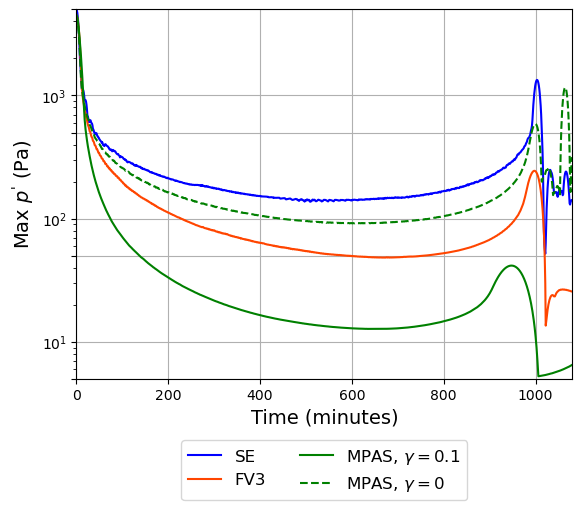

In [10]:
time_mins = time*24*60
end_idx = len(time)

if small_dt:
    # Choose a shorter end time, if only want half an hour, etc
    t_end = -1
    plt.figure()
    plt.semilogy(time_mins[0:t_end], field_se_maxs[0:t_end], label='SE', c='b')
    plt.semilogy(time_mins[0:t_end], field_fv3_maxs[0:t_end], label='FV3', c='orangered')
    plt.semilogy(time_mins[0:t_end], field_mpas_maxs[0:t_end], label=r'MPAS, $\gamma = 0.1$', c='g')
    plt.semilogy(time_mins[0:t_end], field_mpas_no_smdiv_maxs[0:t_end], label=r'MPAS, $\gamma = 0$', c='g', linestyle='--')
    plt.xlim([time_mins[0],time_mins[t_end]])
    if field_name == 'PS':
        plt.ylabel(r"Max $p^'$ (Pa)", size=14)
        plt.ylim([5,5000])
        plt.yticks([5,10,50,100,500,1000,5000])
    else:
        plt.ylabel(f'{field_name} maximum',size=14)
        plt.ylim([0,2])
    plt.xlabel('Time (minutes)', size=14)
    plt.legend(loc='lower center', prop={'size': 12}, bbox_to_anchor=(0.5, -0.35), ncol=2)
    plt.grid()
    if save_the_fig:
        if case == 'p_pert':
            plt.savefig(f'figures/p_pert_{field_name}_dt_1min', bbox_inches='tight')
        elif case == 'acid':
            plt.savefig(f'figures/acid_{field_name}_dt_1min', bbox_inches='tight')
else:
    plt.figure()
    plt.plot(time_mins, field_se_maxs[0:end_idx], label='SE')
    plt.plot(time_mins, field_fv3_maxs, label='FV3')
    plt.plot(time_mins, field_eul_maxs, label='EUL')
    plt.xlim([time_mins[0],time_mins[-1]])
    plt.ylim([0,0.015]) 
    plt.ylabel(f'{field_name} maximum',size=14)
    plt.xlabel('Time (minutes)',size=14)
    #plt.title(f'Acid test, L58, Maximum in the {field_name} field')
    plt.legend(loc='lower center', prop={'size': 12}, bbox_to_anchor=(0.5, -0.25), ncol=2)
    if save_the_fig:
        if case == 'p_pert':
            plt.savefig(f'figures/p_pert_{field_name}_longer', bbox_inches='tight')
        elif case == 'acid':
            plt.savefig(f'figures/acid_{field_name}_longer', bbox_inches='tight')



In [ ]:
# What about comparing the fields??
# Give the time index
#t_idx = 720
t_idx = 1000
t_min = int(np.round(time[t_idx]*24*60, 0))
print(t_min)

if field_name == 'PS':
    se_plot = field_se[t_idx, :, :]-p0
    fv3_plot = field_fv3[t_idx, :, :]-p0
    mpas_plot = field_mpas[t_idx, :, :]-p0
    conts = np.linspace(0,50,11)
    cmap='viridis'
else:
    se_plot = field_se[t_idx, :, :]
    fv3_plot = field_fv3[t_idx, :, :]
    mpas_plot = field_mpas[t_idx, :, :]

print(conts)

fig, axes = plt.subplots(1,3, figsize=(15,5), sharey = True)
ax1, ax2, ax3 = axes

plot1 = ax1.contourf(LON, LAT, se_plot, levels = conts, extend='both', cmap=cmap)
plot2 = ax2.contourf(LON, LAT, fv3_plot, levels = conts, extend='both', cmap=cmap)
plot3 = ax3.contourf(LON, LAT, mpas_plot, levels = conts, extend='both', cmap=cmap)

cb = plt.colorbar(plot3, ax=axes, shrink=0.7, pad=0.15, aspect=60, location='bottom')
if field_name == 'PS':
    ax1.set_title(f'SE \n min = {np.min(se_plot):.1f} Pa \n max = {np.max(se_plot):.1f} Pa', size=14)
    ax2.set_title(f'FV3 \n min = {np.min(fv3_plot):.1f} Pa \n max = {np.max(fv3_plot):.1f} Pa', size=14)
    ax3.set_title(f'MPAS \n min = {np.min(mpas_plot):.1f} Pa \n max = {np.max(mpas_plot):.1f} Pa', size=14)
    cb.set_label('Pressure perturbation (Pa)', size=12)
elif field_name == 'OMEGA850':
    ax1.set_title(f'SE \n min = {np.min(se_plot):.1f} \n max = {np.max(se_plot):.1f}')
    ax2.set_title(f'FV3 \n min = {np.min(fv3_plot):.1f} \n max = {np.max(fv3_plot):.1f}')
    ax3.set_title(f'MPAS \n min = {np.min(mpas_plot):.1f} \n max = {np.max(mpas_plot):.1f}')
    cb.set_label(r'Maximum vertical pressure velocity (Pa s$^{-1}$', size=12)

ax1.set_ylabel('Latitude (deg)', size=14)
ax2.set_xlabel('Longitude (deg)', size=14)

for ax in axes.flatten():
    ax.set_xticks(np.linspace(0,360,7))
    ax.set_aspect('equal')
    
ax2.set_xticks(np.linspace(0,360,7))
ax3.set_xticks(np.linspace(0,360,7))
ax1.set_yticks(np.linspace(-90,90,7))

if save_the_fig:
    if case == 'p_pert':
        plt.savefig(f'figures/p_pert_{field_name}_t{t_min}_mins', bbox_inches='tight')
    elif case == 'acid':
        plt.savefig(f'figures/acid_{field_name}_t{t_min}_mins', bbox_inches='tight')

plt.show()
